In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,Dense,MaxPooling2D,Flatten,Dropout

In [5]:
(X_train,y_train),(X_test,y_test)=mnist.load_data()

In [6]:
print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


In [7]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [8]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1) # (60000, 28,28,1) same meaning

In [9]:
print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

(60000, 28, 28, 1)
(60000,)
(10000, 28, 28, 1)
(10000,)


In [14]:
model = Sequential()

In [15]:
model.add(Conv2D(filters=32,kernel_size=(3,3),activation="relu",input_shape=(28,28,1)))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(
    Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation="relu"
    )
)
model.add(
    MaxPooling2D(pool_size=(2,2))
)
model.add(Flatten())
model.add(Dense(128, activation="relu"))
model.add(Dropout(0.5))
model.add(Dense(10, activation="softmax"))


In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [19]:
history = model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9285 - loss: 0.2339 - val_accuracy: 0.9803 - val_loss: 0.0636
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9737 - loss: 0.0883 - val_accuracy: 0.9855 - val_loss: 0.0465
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9800 - loss: 0.0652 - val_accuracy: 0.9878 - val_loss: 0.0432
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9836 - loss: 0.0535 - val_accuracy: 0.9875 - val_loss: 0.0449
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9872 - loss: 0.0423 - val_accuracy: 0.9888 - val_loss: 0.0369
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9879 - loss: 0.0363 - val_accuracy: 0.9906 - val_loss: 0.0360
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9900 - loss: 0.0325 - val_accuracy: 0.9903 - val_loss: 0.0355
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9910 - loss: 0.0285 -

In [20]:
loss, accuracy = model.evaluate(X_test, y_test)

print("\nTest Loss :", loss)
print("Test Accuracy :", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9930 - loss: 0.0279

Test Loss : 0.027935132384300232
Test Accuracy : 0.9929999709129333


In [21]:
predictions = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [23]:
predictions.shape

(10000, 10)

In [24]:
predicted_classes = np.argmax(predictions, axis=1)

In [25]:
print(predicted_classes[:10])

[7 2 1 0 4 1 4 9 5 9]


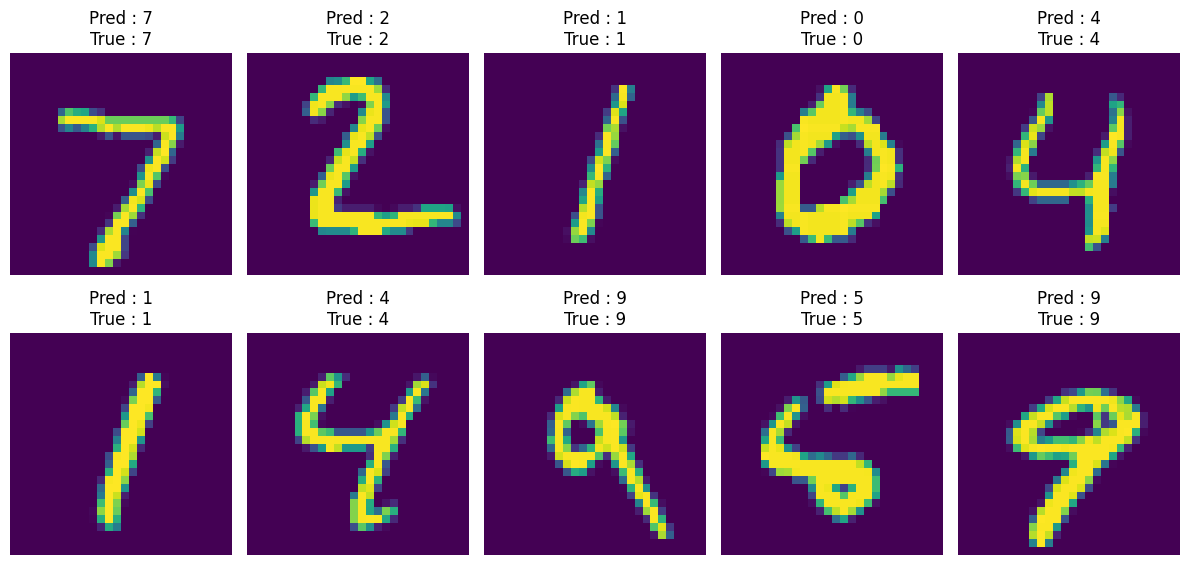

In [28]:
plt.figure(figsize=(12,6))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(X_test[i])

    plt.title(
        f"Pred : {predicted_classes[i]}\nTrue : {y_test[i]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

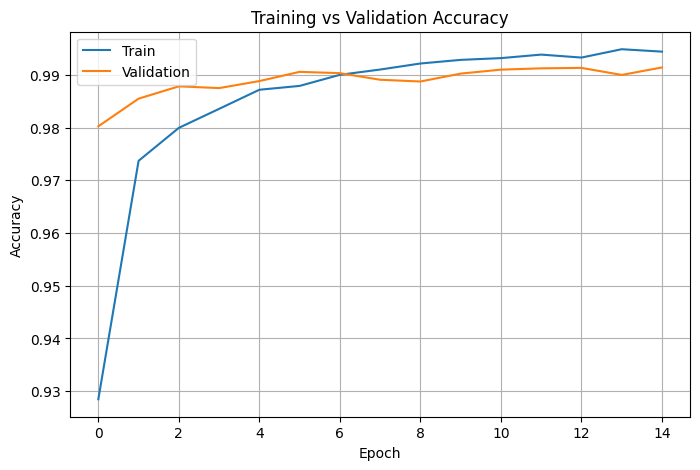

In [29]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("Training vs Validation Accuracy")

plt.legend(["Train","Validation"])

plt.grid(True)

plt.show()

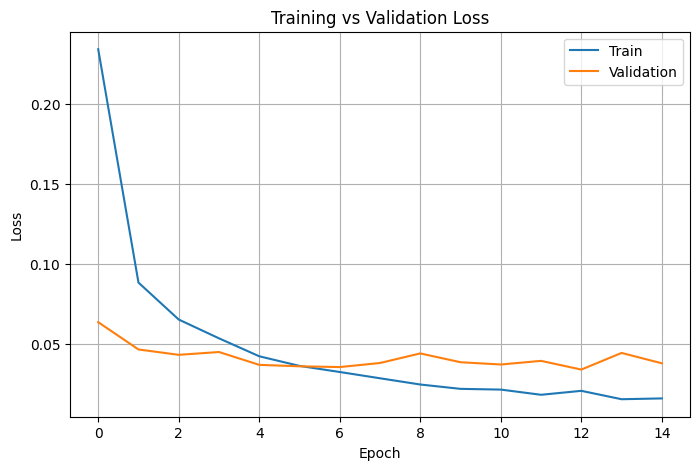

In [30]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend(["Train","Validation"])

plt.grid(True)

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


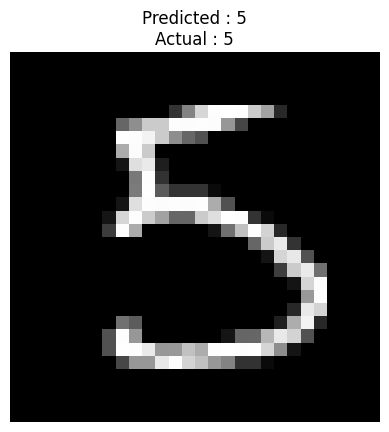

Prediction Probabilities:

[[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]]

Predicted Digit : 5


In [33]:
#16. Predict Single Image
# ============================================

index = 15

image = X_test[index]

prediction = model.predict(image.reshape(1,28,28,1))

predicted_digit = np.argmax(prediction)

plt.imshow(image.reshape(28,28), cmap="gray")
plt.title(f"Predicted : {predicted_digit}\nActual : {y_test[index]}")
plt.axis("off")
plt.show()

print("Prediction Probabilities:\n")
print(np.round(prediction, 6))
print("\nPredicted Digit :", predicted_digit)

In [34]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

In [35]:
accuracy = accuracy_score(y_test, predicted_classes)

print("Accuracy :", accuracy)

Accuracy : 0.993


In [36]:
print(classification_report(y_test, predicted_classes))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       1.00      1.00      1.00      1135
           2       0.99      1.00      0.99      1032
           3       0.99      1.00      0.99      1010
           4       0.99      1.00      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       1.00      0.99      1.00       974
           9       1.00      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [38]:
cm = confusion_matrix(y_test, predicted_classes)

print(cm)

[[ 974    0    2    0    0    0    3    1    0    0]
 [   3 1130    0    0    0    1    1    0    0    0]
 [   1    0 1030    0    0    0    1    0    0    0]
 [   0    0    1 1006    0    1    0    1    1    0]
 [   0    0    0    0  978    0    3    0    1    0]
 [   0    0    0    8    0  882    1    0    0    1]
 [   2    2    0    0    1    5  948    0    0    0]
 [   0    1    8    0    0    0    0 1019    0    0]
 [   1    0    1    1    0    0    0    1  968    2]
 [   0    0    0    1    6    4    0    3    0  995]]


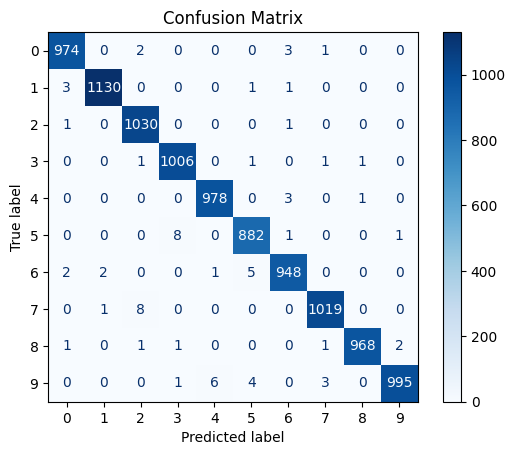

In [39]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=range(10)
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.show()